# Variaciones del mismo digito


### En este notebook se observan distintas reconstrucciones del mismo dígito


#### Datos

Se usaron los datos de MNIST para entrenar los modelos y visualizar las variaciones por dígito (genericamente clase).


#### Modelo


Se usaron los modelos de diminesiones 128_2 y 256_128 (intermedia y latente respectivamente) para visualizar.


In [7]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.trained_models import load


cvae_0 = load.cvae(lat=64,inter=128,dataset="mnist")

cvae_1 = load.cvae(inter=256,lat=128,dataset="mnist")

cvae_2 = load.cvae(lat=2, inter=128,dataset="mnist")

predictor = load.predictor("mnist")

data =  load.data("mnist")

x_train = data["x_train"]
x_train_1 = data["x_train_1"]
y_train = data["y_train"]
y_train_1 = data["y_train_1"]
x_test = data["x_test"]
y_test  =data["y_test"]

models = load.all_models()

Usando mnist como dataset
Encontrados 8 pares de modelos.


## Visualizaciones:

Variaciones por dígito de cvae_0


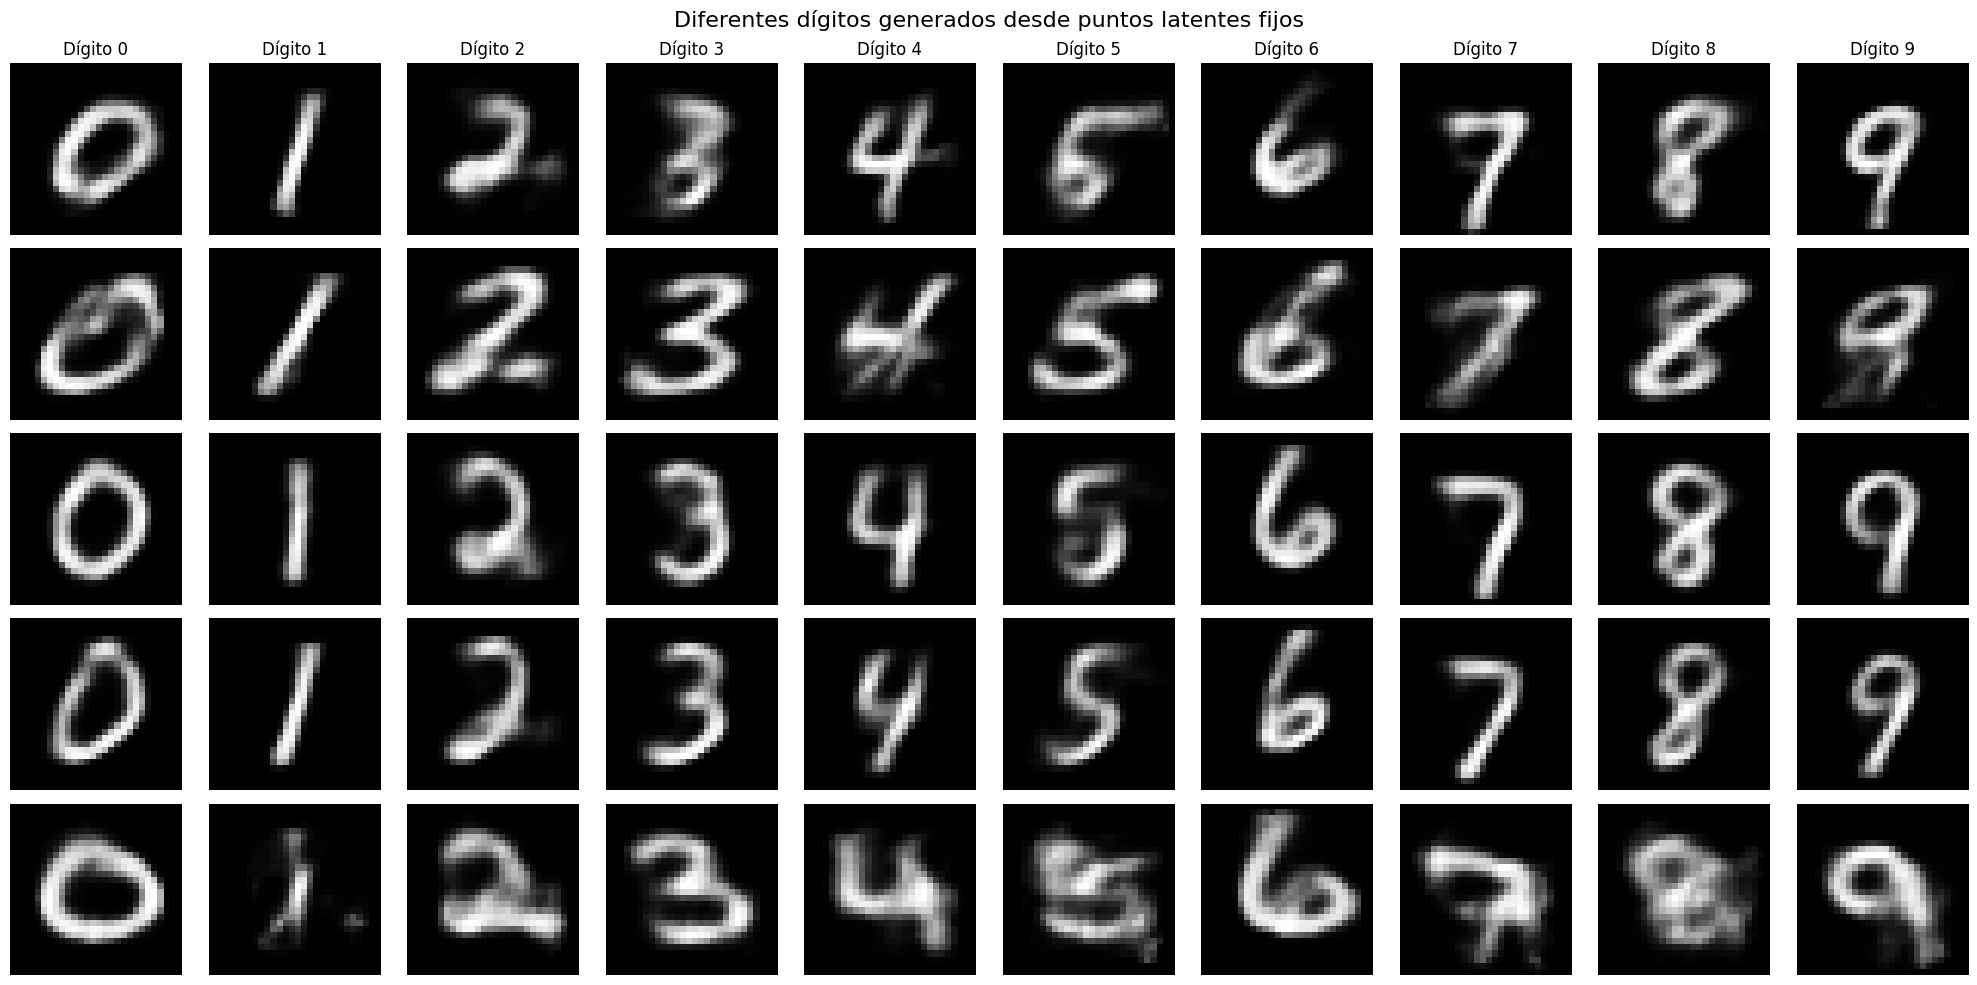

In [8]:
import visualizations.visualizations as vis

puntos=vis.variantes_punto_fijo(cvae=cvae_0) #se toma un punto del espacio latente para las reconstrucciones

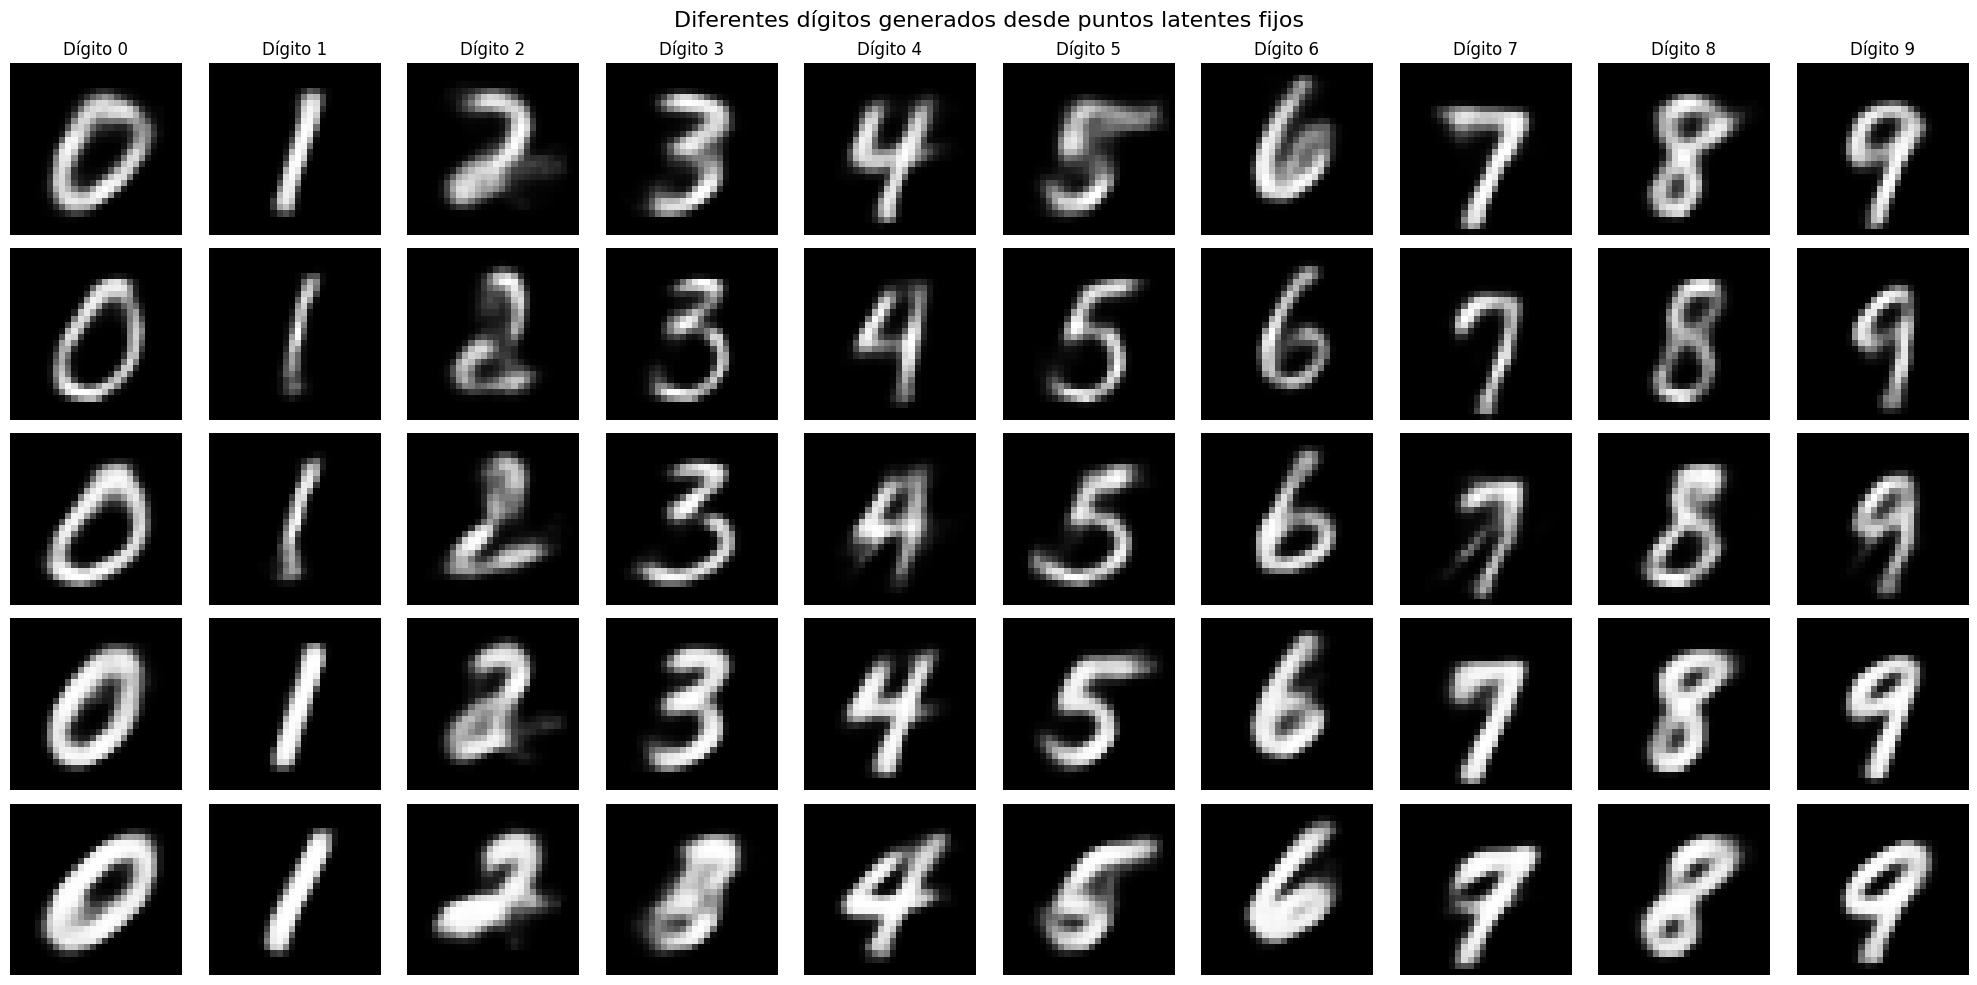

In [9]:
puntos=vis.variantes_punto_fijo(cvae=cvae_1)

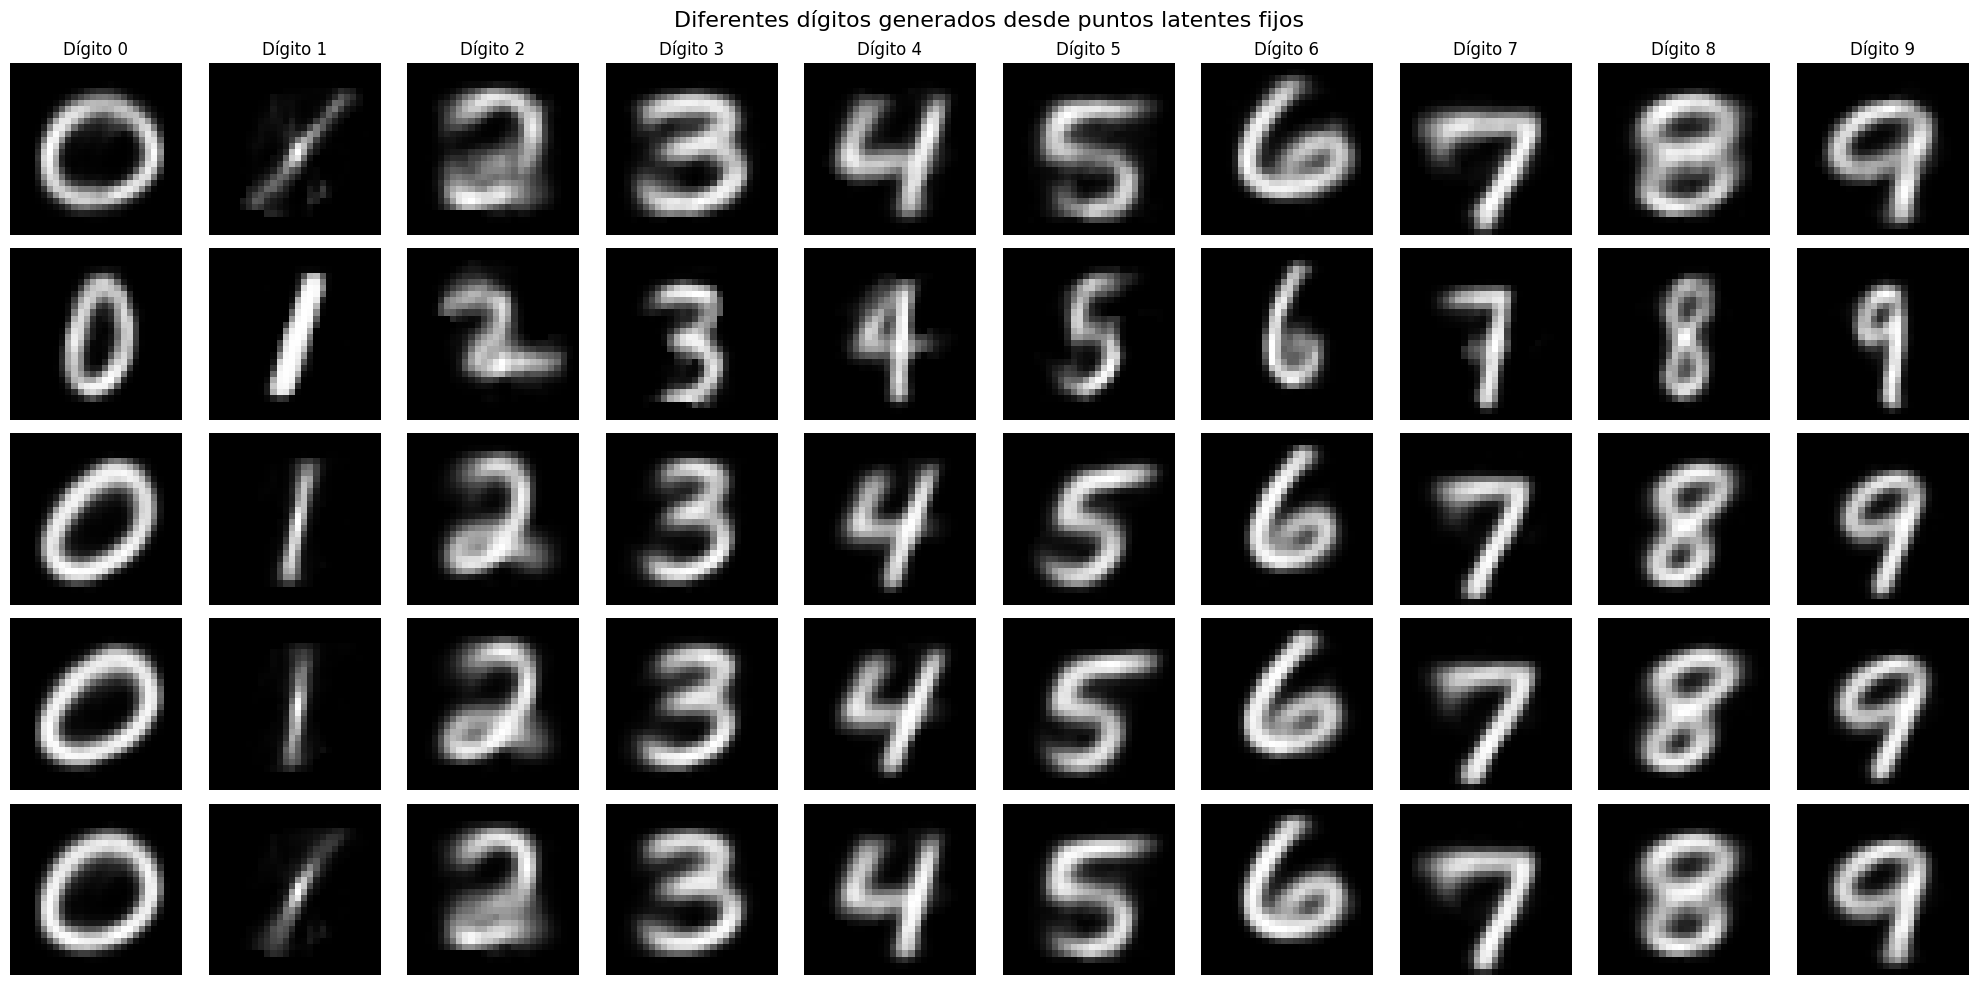

In [10]:
puntos=vis.variantes_punto_fijo(cvae=cvae_2)

Para ambos modelos parece haber una buena reconstrucción de dígitos. Bastante peor en el caso del modelo cvae_0. los modelos fueron entrenados hasta que earystop los freno.




## Condiciones anómalas

condición en el decoder y enconder en 0 o aleatoreo


[[0.75865718 0.08634555 0.89375752 0.27283121 0.55146377 0.30725498
  0.20628451 0.51454102 0.38804707 0.33972746]
 [0.47829798 0.84550914 0.5617799  0.09581032 0.81359061 0.15833461
  0.61871089 0.10008976 0.72390175 0.16283062]
 [0.3188836  0.70455746 0.38885474 0.82532956 0.58160366 0.15448916
  0.56698375 0.17231093 0.95614467 0.77631896]
 [0.95734429 0.6563575  0.19363633 0.09956119 0.25018682 0.02634623
  0.22179733 0.0570204  0.53742395 0.08457956]
 [0.91093377 0.26712822 0.86183849 0.71652598 0.89809708 0.34172281
  0.12803763 0.77647404 0.08217148 0.23836   ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


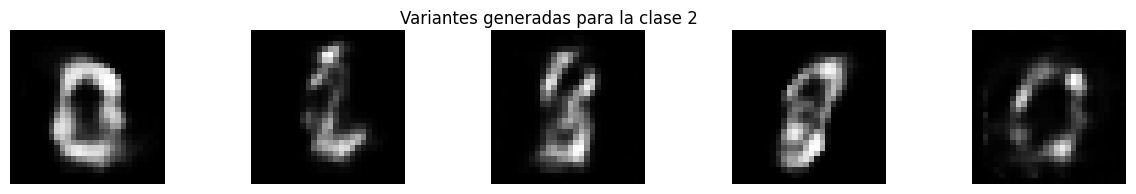

array([[-4.83103035e-01,  5.58325293e-01,  1.27320409e-01,
         2.62764081e-01, -1.12383124e+00,  5.81320959e-03,
        -1.80540328e+00, -1.03153822e+00,  2.89691640e-01,
         7.05906879e-01, -4.74064670e-02, -2.11378015e-01,
        -2.26453741e-01,  2.09036856e-01, -7.25561247e-01,
        -1.61840895e+00,  2.48398300e-01, -1.84233998e+00,
         4.05047894e-01, -6.73942141e-01, -7.93481972e-01,
         2.11140669e+00, -5.75455813e-01,  1.06705392e-01,
        -9.86281893e-01,  9.86081928e-01,  2.85957348e-01,
         8.57838501e-01, -2.25109781e+00,  8.31812197e-01,
         3.61906449e-01,  1.72393425e+00, -1.19810658e+00,
        -3.24736035e-01, -6.01236465e-01,  7.39793155e-01,
         1.01239097e+00, -1.12626700e+00,  5.63680723e-01,
        -4.42371269e-01, -4.28106856e-01, -3.96018228e-01,
        -1.28328404e+00, -1.39091788e+00, -8.50318435e-01,
        -6.64758613e-01,  1.20965812e-01, -2.10679875e-01,
        -4.72977101e-01,  6.75913512e-01, -3.17805554e-0

In [8]:
import project.visualizations.visualizations as vis
import importlib
import numpy as np

importlib.reload(vis)
num_variantes = 5
custom_condition = np.zeros(shape=(num_variantes, 10))
custom_condition = np.random.uniform(0,1,size=(num_variantes,10))
"""
1) probar poner 0s al encoder.

2) entrenar un encoder sin clases en la entrada (quizas ponerle 0 en la entrada, sino cambiar 
                                                la arquitectura para que no tenga condicion. Verficar si es lo mismo)


"""
print(custom_condition)
vis.variantes(
    cvae=cvae_0,
    condicion_id=2,
    num_variantes=num_variantes,
    custom_condition=custom_condition,
)